<a href="https://colab.research.google.com/drive/1eelMO3Di5B3BVUXOIYe9Wrle5dRajM6U?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D MRI classification

Second half of the seminar. Last time we classified sex from FreeSurfer *tables* - hand-crafted morphometry features. Now we throw the raw 3D volume at a convolutional net and let it find its own features. Same target (male/female), completely different modelling philosophy.

Data is the [IXI dataset](https://brain-development.org/ixi-dataset/): ~600 T1-weighted brains from three London hospitals, in NIfTI. Released under CC BY-SA 3.0 - if you use it anywhere, cite the IXI website.

A fair warning up front: this notebook downloads ~4.5 GB and trains a 3D CNN. On a Colab GPU it's fine; on CPU it will crawl. Make sure Runtime -> Change runtime type -> GPU is set before you run anything heavy.

## Local setup - Python 3.12

This notebook is configured for **CPython 3.12**. A GPU is strongly recommended: the 3D DenseNet can run on a CPU, but training will be very slow.

You are strongly recommended to use Google Colab runtime.

Keep this notebook and `requirements.txt` in the same directory. Create a dedicated virtual environment before opening the notebook.

### 1. Create and activate the environment

**macOS or Linux**

```bash
python3.12 --version
python3.12 -m venv .venv
source .venv/bin/activate

python -m pip install --upgrade pip setuptools wheel
python -m pip install -r requirements.txt

python -m ipykernel install --user \
  --name classification-3d-py312 \
  --display-name "Python 3.12 (3D classification)"

jupyter lab
```

**Windows PowerShell**

```powershell
py -3.12 --version
py -3.12 -m venv .venv
.\.venv\Scripts\Activate.ps1

python -m pip install --upgrade pip setuptools wheel
python -m pip install -r requirements_3d_classification_python312.txt

python -m ipykernel install --user `
  --name classification-3d-py312 `
  --display-name "Python 3.12 (3D classification)"

jupyter lab
```

After Jupyter opens, select **Kernel -> Change Kernel -> Python 3.12 (3D classification)**.

The requirements file installs the standard PyPI build of PyTorch. For an NVIDIA CUDA-specific build, install the appropriate PyTorch wheel for your CUDA version first, then install the remaining requirements. The exact command depends on the operating system, CUDA toolkit, and GPU driver.

Imports. `pandas`/`numpy` for the tabular side, `torch` for the network, and `monai` — think of it as torch with a lot of medical-imaging conveniences bolted on (readers, transforms, ready-made 3D architectures).

In [1]:
# For Colab runtime run this cell
# !pip install -q "monai[nibabel,tqdm]==1.3.2"

In [2]:
import logging, os, sys, shutil, tempfile
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.tensorboard import SummaryWriter

import monai
from monai.utils.misc import set_determinism
from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import DataLoader, ImageDataset
from monai.metrics import ROCAUCMetric
from monai.transforms import (
    EnsureChannelFirst, Compose, RandRotate90, Resize, ScaleIntensity,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = torch.cuda.is_available()
if device.type != "cuda":
    print("WARNING: no GPU visible - training will be extremely slow. \
    Switch the runtime to GPU.")

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
print_config()

MONAI version: 1.3.2
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 59a7211070538586369afd4a01eca0a7fe2e742e
MONAI __file__: /workspace/seminar5_neuroml/3d_classification/.venv/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.1
Pillow version: 12.3.0
Tensorboard version: 2.18.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: NOT INSTALLED or UNKNOWN VERSION.
tqdm version: 4.70.0
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 2.2.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED 

Fix the seeds so reruns match.

In [3]:
set_determinism(seed=42)

## Getting the data

In [4]:
directory = "classification"
root_dir = tempfile.mkdtemp(prefix="classification_") if directory is None else os.path.abspath(directory)
os.makedirs(root_dir, exist_ok=True)
print(f"Working directory: {root_dir}")

Working directory: /workspace/seminar5_neuroml/3d_classification/classification


Download data, namely ixi.tar and IXI.xls files, from https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA?path=%2FSeminar%205%2F3d_classification. \
Place the files into the Working directory (root_dir). \
Navigate into the Working directory and run:

```bash
mkdir ixi
tar -xf ixi.tar -C ixi
```

In [7]:
for entry in sorted(os.listdir(root_dir)):
    print(entry)

IXI.xls
ixi
ixi.tar


Quick sanity-check that the volumes actually loaded, by plotting one. `nilearn` gives us the standard three-plane anatomical view basically for free.

/workspace/seminar5_neuroml/3d_classification/.venv/lib/python3.12/site-packages/nilearn/image/resampling.py:867: UserWarning: Casting data from int32 to float32
  return resample_img(


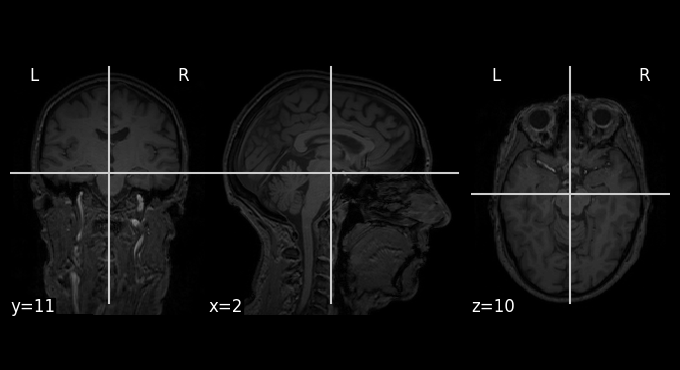

In [8]:
import nilearn
from nilearn import plotting

img = nilearn.image.load_img(glob(f'{root_dir}/ixi/*')[0])
plotting.plot_anat(img)

## Matching images to labels

The demographics live in a spreadsheet, the images in a folder, and we need to line them up by subject id. A couple of gotchas:

- not every scan has a demographics row (and vice versa), so we intersect the two,
- ids repeat in the spreadsheet, so we drop duplicates,
- **order matters**: the labels array has to line up with the images list element-for-element, so after filtering we sort both the same way.

The label map: IXI codes sex as 1=male, 2=female. We remap to 1=male, 0=female so it's a clean binary target.

In [10]:
df = pd.read_excel(f"{root_dir}/IXI.xls")
df.head()

,IXI_ID,"SEX_ID (1=m, 2=f)",HEIGHT,WEIGHT,ETHNIC_ID,MARITAL_ID,OCCUPATION_ID,QUALIFICATION_ID,DOB,DATE_AVAILABLE,STUDY_DATE,AGE
0,1,1,170,80,2,3,5,2,1968-02-22,0,NaT,NaN
1,2,2,164,58,1,4,1,5,1970-01-30,1,2005-11-18,35.800137
2,12,1,175,70,1,2,1,5,1966-08-20,1,2005-06-01,38.781656
3,13,1,182,70,1,2,1,5,1958-09-15,1,2005-06-01,46.710472
4,14,2,163,65,1,4,1,5,1971-03-15,1,2005-06-09,34.236824


In [11]:
# subject id is the number embedded in the filename: IXI423-IOP-0974-T1.nii.gz -> 423
def id_from_path(p):
    return int(os.path.basename(p).split('-')[0][3:])

image_paths = glob(f'{root_dir}/ixi/*')
ids = [id_from_path(p) for p in image_paths]

# keep only subjects present in both, drop duplicate rows
df = df[df.IXI_ID.isin(ids)].drop_duplicates(subset=['IXI_ID'])
df['SEX_ID (1=m, 2=f)'] = df['SEX_ID (1=m, 2=f)'].map({1: 1, 2: 0})  # m=1, f=0

# build images + labels TOGETHER, in one shared order, straight off the dataframe.
# (going through df keeps the two perfectly aligned - no separate sort to drift out of sync)
id_to_path = {id_from_path(p): p for p in image_paths}
df = df[df.IXI_ID.isin(id_to_path)]
images = [id_to_path[i] for i in df.IXI_ID.values]
labels = df['SEX_ID (1=m, 2=f)'].values

# guard: if these ever drift apart, everything downstream is silently wrong
assert len(images) == len(labels), (len(images), len(labels))

In [12]:
len(images), len(labels)

(566, 566)

Peek at a few pairs to confirm the image-label alignment looks sane.

In [13]:
list(zip([os.path.basename(i) for i in images[:5]], labels[:5]))

[('IXI002-Guys-0828-T1.nii.gz', 0),
 ('IXI012-HH-1211-T1.nii.gz', 1),
 ('IXI013-HH-1212-T1.nii.gz', 1),
 ('IXI014-HH-1236-T1.nii.gz', 0),
 ('IXI015-HH-1258-T1.nii.gz', 1)]

## Datasets, transforms, and a *proper* split

Preprocessing per volume:

- **ScaleIntensity** - MRI voxel values aren't standardized the way 0-255 photos are; they drift between scanners. Rescale each volume to [0,1] so one bright scan doesn't dominate.
- **EnsureChannelFirst** - add the channel dim the network expects.
- **Resize to 96³** - uniform shape, and small enough to actually train in a seminar.
- **RandRotate90** (train only) - cheap augmentation. We deliberately leave it *off* for val/test so evaluation is deterministic.

In [14]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(images))
train_idx, tmp_idx = train_test_split(idx, test_size=0.30, stratify=labels, random_state=0)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=labels[tmp_idx], random_state=0)

def subset(indices):
    return [images[i] for i in indices], labels[indices]

train_x, train_y = subset(train_idx)
val_x, val_y = subset(val_idx)
test_x, test_y = subset(test_idx)

# sanity: no subject id appears in more than one split
assert not (set(map(id_from_path, train_x)) & set(map(id_from_path, val_x)))
assert not (set(map(id_from_path, train_x)) & set(map(id_from_path, test_x)))
print(f"train {len(train_x)} | val {len(val_x)} | test {len(test_x)}")

train 396 | val 85 | test 85


In [15]:
train_transforms = Compose([
    ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96)), RandRotate90()
])
val_transforms = Compose([
    ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))
])

train_ds = ImageDataset(image_files=train_x, labels=train_y, transform=train_transforms)
val_ds = ImageDataset(image_files=val_x, labels=val_y, transform=val_transforms)
test_ds = ImageDataset(image_files=test_x, labels=test_y, transform=val_transforms)

num_workers = 0 if os.name == "nt" else 2
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=num_workers, pin_memory=pin_memory)

# peek at one batch to confirm shapes: (B, C, 96, 96, 96)
im, lb = monai.utils.misc.first(train_loader)
print(type(im).__name__, im.shape, lb)

MetaTensor torch.Size([4, 1, 96, 96, 96]) tensor([0, 1, 0, 0])


## Network, loss, optimizer

`DenseNet121` in its 3D form, straight from MONAI. Two output logits (female/male), cross-entropy loss, Adam.

`max_epochs = 4` keeps it seminar-sized. That's *not* enough to squeeze the dataset - expect a decent-but-not-amazing number. Bump it to ~10 at home and it climbs a lot. We validate every couple of epochs and keep the best checkpoint.

In [16]:
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
auc_metric = ROCAUCMetric()

max_epochs = 4
val_interval = 2
ckpt_path = "best_metric_model_classification3d_array.pth"

## Training

TensorBoard, if you want the live curves. Harmless to skip.

In [17]:
%load_ext tensorboard
%tensorboard --logdir runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/workspace/seminar5_neuroml/3d_classification/.venv/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/workspace/seminar5_neuroml/3d_classification/.venv/lib/python3.12/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/workspace/seminar5_neuroml/3d_classification/.venv/lib/python3.12/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

Standard PyTorch loop.

In [19]:
writer = SummaryWriter()

best_metric, best_metric_epoch = -1.0, -1
epoch_loss_values, metric_values = [], []

saved_ckpt = False

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss, step = 0.0, 0

    for batch_data in train_loader:
        step += 1
        inputs, lbls = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, lbls)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        probs, trues = [], []
        with torch.no_grad():
            for val_data in val_loader:
                vx, vy = val_data[0].to(device), val_data[1].to(device)
                logits = model(vx)
                probs.append(torch.softmax(logits, dim=1)[:, 1].cpu())
                trues.append(vy.cpu())
        probs = torch.cat(probs)
        trues = torch.cat(trues)

        auc_metric.reset()
        auc_metric(probs.unsqueeze(1), trues.unsqueeze(1))
        auc = auc_metric.aggregate()
        acc = ((probs > 0.5).long() == trues).float().mean().item()
        metric_values.append(auc)
        writer.add_scalar("val_auc", auc, epoch + 1)
        print(f"  val AUC: {auc:.4f} | val acc: {acc:.4f}")

        if auc > best_metric:
            best_metric, best_metric_epoch = auc, epoch + 1
            torch.save(model.state_dict(), ckpt_path)
            saved_ckpt = True
            print(f" saved new best model (AUC {auc:.4f})")

print(f"training done. best val AUC {best_metric:.4f} at epoch {best_metric_epoch}")
writer.close()

----------
epoch 1/4
1/99, train_loss: 0.1725
2/99, train_loss: 0.6310
3/99, train_loss: 0.1594
4/99, train_loss: 0.0813
5/99, train_loss: 0.9683
6/99, train_loss: 0.0663
7/99, train_loss: 0.3358
8/99, train_loss: 0.0878
9/99, train_loss: 0.6603
10/99, train_loss: 0.0946
11/99, train_loss: 0.5912
12/99, train_loss: 0.1082
13/99, train_loss: 0.0573
14/99, train_loss: 0.1825
15/99, train_loss: 0.5160
16/99, train_loss: 0.1986
17/99, train_loss: 0.2788
18/99, train_loss: 0.3662
19/99, train_loss: 1.4491
20/99, train_loss: 0.1256
21/99, train_loss: 0.3853
22/99, train_loss: 0.8252
23/99, train_loss: 0.2685
24/99, train_loss: 0.1619
25/99, train_loss: 0.2142
26/99, train_loss: 0.2563
27/99, train_loss: 0.3665
28/99, train_loss: 0.6952
29/99, train_loss: 0.1207
30/99, train_loss: 1.4773
31/99, train_loss: 0.4724
32/99, train_loss: 0.4316
33/99, train_loss: 0.3387
34/99, train_loss: 0.3486
35/99, train_loss: 0.1111
36/99, train_loss: 0.2308
37/99, train_loss: 0.5225
38/99, train_loss: 0.1817


## Loss and metric curves

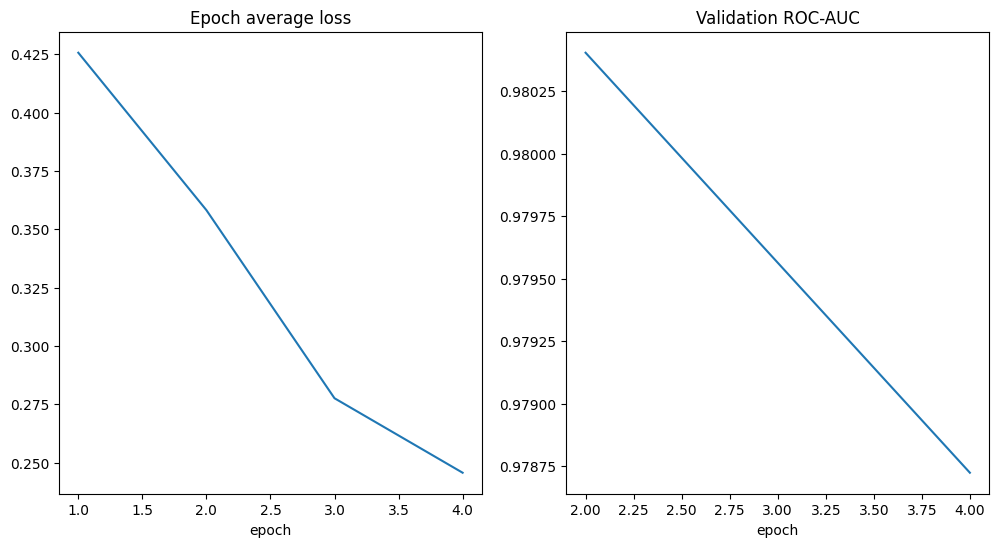

In [20]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch average loss")
plt.xlabel("epoch")
plt.plot([i + 1 for i in range(len(epoch_loss_values))], epoch_loss_values)

plt.subplot(1, 2, 2)
plt.title("Validation ROC-AUC")   # actually AUC now, not accuracy mislabelled as AUC
plt.xlabel("epoch")
plt.plot([val_interval * (i + 1) for i in range(len(metric_values))], metric_values)
plt.show()

## Final evaluation on the held-out test set

This is the set the model never saw during training *or* validation, so it's the honest estimate. We load the best checkpoint if training saved one; otherwise we just evaluate the model as it stands (useful when you've only run a couple of quick epochs and nothing beat the initial AUC yet).

In [21]:
if saved_ckpt and os.path.isfile(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("loaded best checkpoint")
else:
    print("no checkpoint saved - evaluating current model weights")

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for test_data in test_loader:
        tx, ty = test_data[0].to(device), test_data[1].to(device)
        pred = model(tx).argmax(dim=1)
        y_true.extend(ty.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

/tmp/ipykernel_859566/2883996660.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


loaded best checkpoint


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=['f', 'm'], digits=4))

              precision    recall  f1-score   support

           f     1.0000    0.5957    0.7467        47
           m     0.6667    1.0000    0.8000        38

    accuracy                         0.7765        85
   macro avg     0.8333    0.7979    0.7733        85
weighted avg     0.8510    0.7765    0.7705        85



### Things to try

- **Train longer.** 4 epochs barely warms it up; 10-15 changes the picture.
- **Compare to part 1.** The FreeSurfer logistic model got ~0.87 AUC from hand-made features in seconds. Does a 3D CNN on raw volumes actually beat it, given how little we trained? When is the heavy model worth it?
- **What is it looking at?** Same trap as last time - is the CNN learning sex-specific structure, or just overall brain size? Occlusion or Grad-CAM would tell you.
- **Augment more.** One `RandRotate90` is timid. Flips, small affines, intensity jitter.

## Cleanup

In [23]:
if directory is None:
    shutil.rmtree(root_dir)